# HealthContradict - Exploratory Data Analysis

In [1]:
%pip install numpy pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [4]:
import json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 120)
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# Resolve paths relative to the repo root (this notebook lives at the root).
DATASET_PATH   = Path("dataset_ready.jsonl")

if DATASET_PATH.exists():
    print(f"{'OK ' if DATASET_PATH else 'MISSING'} {DATASET_PATH}")

OK  dataset_ready.jsonl


In [5]:
# ---- Load all three files -------------------------------------------------
ds = pd.read_json(DATASET_PATH, lines=True)

print("dataset_ready.jsonl :", ds.shape)

dataset_ready.jsonl : (920, 6)


## 1. `dataset_ready.jsonl` — the model-ready dataset

Each row is one *instance*: a query plus the two documents of a contradiction pair.

In [14]:
ds.head(3)

,instance_id,topic_id,query,query_stance,doc_a,doc_b
0,0,6,Is amygdalin or laetrile an effective cancer treatment?,no,"* When open a local search file in Internet Explorer on Windows XP SP 2, the content may be blocked. To open the fil...",Vitamins - Vitamin - Vitamins Are Needed For A Healthy Lifestyle - Diet and Health.net normal functioning of our bod...
1,1,6,Is amygdalin or laetrile an effective cancer treatment?,no,No. 26568 - State of West Virginia v. Donna Jean Poling I dissent from the majority opinion because I believe that t...,Miracle II Products | Suggested Uses | M II Testimonials | Order Miracle II | Health News | Links | Business Opportu...
2,2,6,Is amygdalin or laetrile an effective cancer treatment?,no,Topics in This SectionOverviewQuestions and Answers About AromatherapyChanges to This Summary (03/26/2010)General CA...,"Home » Cancer Information » Complementary & Alternative Medicine » Acupuncture » Acupuncture applies needles, heat, ..."


In [15]:
print(ds.iloc[0].doc_a)

* When open a local search file in Internet Explorer on Windows XP SP 2, the content may be blocked. To open the file correctly, please click the Information Bar on the top of the browser window, and select "Allow Blocked Content". * There will not be such problem after you upload the file to a web server. * To display this page, you need a web browser with JavaScript support. that Laetrile is both safe and effective in the treatment of Hanover. He is a pioneer in the medical use of cobalt and is listed in Who�s Who in World Science and has been the He is one of the world�s most famous and respected cancer New Brunswick. He was a Fellow in chemistry and a Fellow in they did not even receive what we consider the basic dose of I ... have specialized in oncology [the study of tumors] for the past eighteen years. For the same number of years I have from the United States who brought it to his. attention and urged him to treat her with it. The woman recovered, and Dr. and use. Since that ti

In [16]:
print("Schema & dtypes:")
print(ds.dtypes)
print("\nMissing values per column:")
print(ds.isna().sum())
print("\nRows:", len(ds))
print("Unique instance_id:", ds["instance_id"].nunique())
print("Unique topic_id   :", ds["topic_id"].nunique())
print("Unique queries    :", ds["query"].nunique())

Schema & dtypes:
instance_id     int64
topic_id        int64
query             str
query_stance      str
doc_a             str
doc_b             str
dtype: object

Missing values per column:
instance_id     0
topic_id        0
query           0
query_stance    0
doc_a           0
doc_b           0
dtype: int64

Rows: 920
Unique instance_id: 920
Unique topic_id   : 81
Unique queries    : 81


query_stance
no     676
yes    244
Name: count, dtype: int64

Proportions:
query_stance
no     0.735
yes    0.265
Name: count, dtype: float64


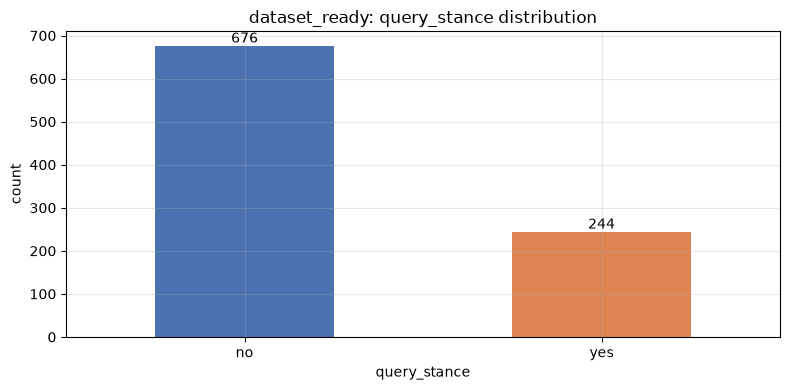

In [17]:
# query_stance distribution: what is the "correct" answer to the query?
vc = ds["query_stance"].value_counts()
print(vc)
print("\nProportions:")
print((vc / vc.sum()).round(3))

ax = vc.plot(kind="bar", color=["#4C72B0", "#DD8452"], rot=0)
ax.set_title("dataset_ready: query_stance distribution")
ax.set_xlabel("query_stance"); ax.set_ylabel("count")
for i, v in enumerate(vc):
    ax.text(i, v, str(v), ha="center", va="bottom")
plt.tight_layout(); plt.show()

Instances per topic — describe():
count    81.000000
mean     11.358025
std      14.014554
min       1.000000
25%       2.000000
50%       5.000000
75%      19.000000
max      77.000000
dtype: float64


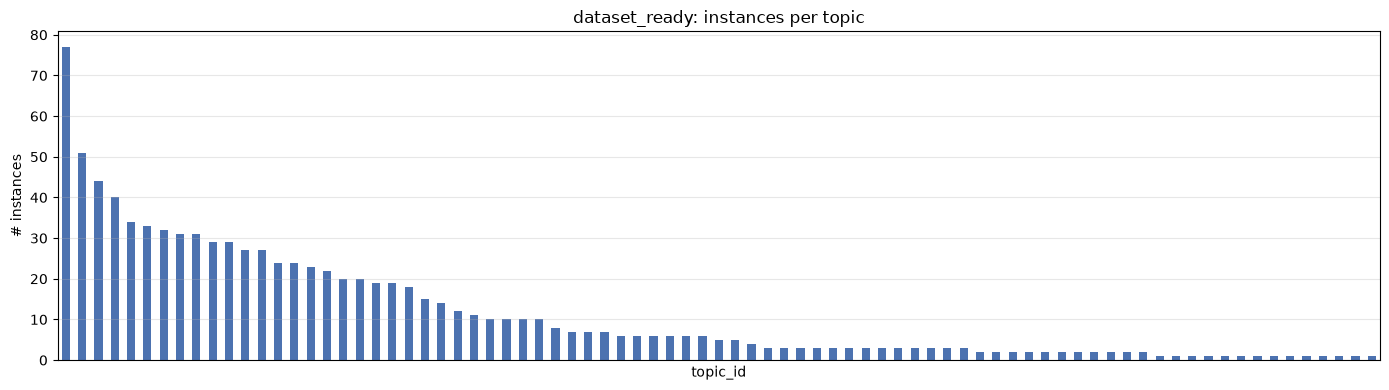

In [18]:
# Instances per topic
per_topic = ds.groupby("topic_id").size().sort_values(ascending=False)
print("Instances per topic — describe():")
print(per_topic.describe())

ax = per_topic.plot(kind="bar", figsize=(14, 4), color="#4C72B0")
ax.set_title("dataset_ready: instances per topic")
ax.set_xlabel("topic_id"); ax.set_ylabel("# instances")
ax.set_xticks([]) if per_topic.size > 60 else None
plt.tight_layout(); plt.show()

In [20]:
# Define small helpers for text length analysis
def n_words(s):
    return len(str(s).split())

def n_chars(s):
    return len(str(s))

Query length in words — describe():
count    81.00
mean      6.90
std       2.19
min       3.00
25%       5.00
50%       7.00
75%       8.00
max      15.00
Name: query, dtype: float64


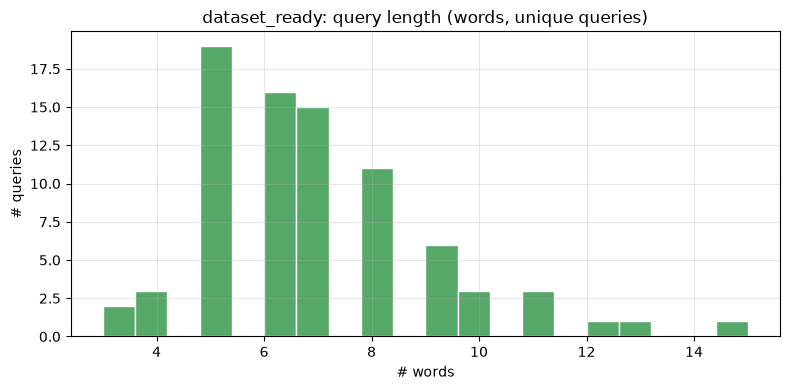


Sample queries:
 - Is amygdalin or laetrile an effective cancer treatment?
 - Can melatonin be used to reduce jet lag?
 - Can exercises relieve lower back pain?
 - Is male circumcision helpful in reducing heterosexual men's chances of getting HIV?
 - Find documents that discuss using antidepressants for helping to manage or relieve lower back pain.
 - Can magnesium prevent muscle cramps?
 - Can steroids be used as a treatment for spinal cord injury?
 - Can antibiotics be used as a treatment for whooping cough (pertussis)?


In [21]:
# Query length distribution (queries are short questions)
ql = ds.drop_duplicates("query")["query"].map(n_words)
print("Query length in words — describe():")
print(ql.describe().round(2))

ax = ql.plot(kind="hist", bins=20, color="#55A868", edgecolor="white")
ax.set_title("dataset_ready: query length (words, unique queries)")
ax.set_xlabel("# words"); ax.set_ylabel("# queries")
plt.tight_layout(); plt.show()

print("\nSample queries:")
for q in ds["query"].drop_duplicates().head(8):
    print(" -", q)

       doc_a_words  doc_b_words
count        920.0        920.0
mean        2088.8       1927.9
std         2463.0       2379.9
min           38.0         22.0
25%          707.5        613.0
50%         1231.5       1052.0
75%         2376.2       2281.5
max        26124.0      25928.0


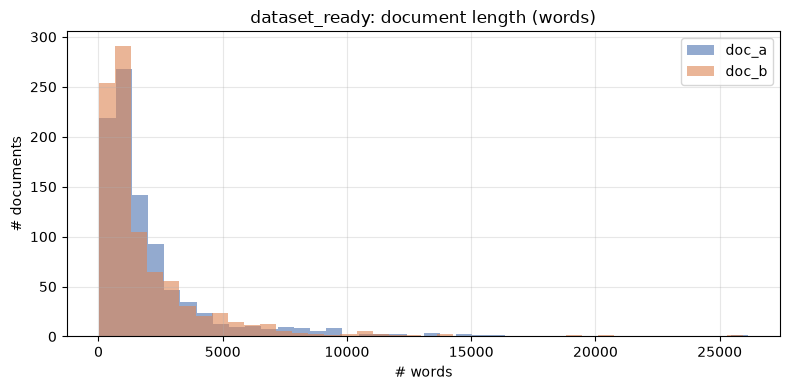

In [22]:
# Document length distributions for doc_a vs doc_b
len_df = pd.DataFrame({
    "doc_a_words": ds["doc_a"].map(n_words),
    "doc_b_words": ds["doc_b"].map(n_words),
})
print(len_df.describe().round(1))

fig, ax = plt.subplots()
ax.hist(len_df["doc_a_words"], bins=40, alpha=0.6, label="doc_a", color="#4C72B0")
ax.hist(len_df["doc_b_words"], bins=40, alpha=0.6, label="doc_b", color="#DD8452")
ax.set_title("dataset_ready: document length (words)")
ax.set_xlabel("# words"); ax.set_ylabel("# documents"); ax.legend()
plt.tight_layout(); plt.show()